# Clustering analysis

In [ ]:
from pathlib import Path
import pandas as pd
notebook_dir = Path().resolve()
FEATURE_PATH = notebook_dir.parents[1]  / "1" / "Features" 
PATIENT_PROFILES_NAME = "patient_profile_clean.csv"

patients = pd.read_csv(FEATURE_PATH / PATIENT_PROFILES_NAME)

In [2]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4289 entries, 0 to 4288
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   subject_id               4289 non-null   int64  
 1   age                      4289 non-null   float64
 2   temp_max                 4289 non-null   float64
 3   sbp_max                  4289 non-null   float64
 4   hr_max                   4289 non-null   float64
 5   rr_max                   4289 non-null   float64
 6   spo2_min                 4289 non-null   float64
 7   lvef_min                 4289 non-null   float64
 8   hf_severity_max          4289 non-null   int64  
 9   lv_dilated               4289 non-null   float64
 10  mitral_regurgitation     4289 non-null   float64
 11  coronary_artery_disease  4289 non-null   float64
 12  atrial_fibrillation      4289 non-null   float64
 13  severe_stenosis          4289 non-null   float64
 14  pulmonary_hypertension  

In [3]:
missing_cols = patients.columns[patients.isna().sum() > 0]
print(missing_cols)


Index(['total_tests', 'perc_invalid', 'k_max', 'glu_max', 'creat_max',
       'k_abnormal_ratio', 'glu_abnormal_ratio', 'creat_abnormal_ratio',
       'total_procedures', 'n_days_span_y'],
      dtype='object')


In [4]:
patients_missing = patients[missing_cols]
patients_missing.head()

,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
0,217.0,0.398,4.5,163.0,2.3,0.000,0.679,1.000,7.0,0.0
1,49.0,0.347,3.6,395.0,1.0,0.500,1.000,0.000,2.0,0.0
2,364.0,0.330,5.6,140.0,1.2,0.176,0.688,0.188,8.0,14.0
3,24.0,0.250,5.1,92.0,1.0,0.000,0.000,0.000,NaN,NaN
4,135.0,0.319,4.1,111.0,1.0,0.000,0.800,0.000,2.0,0.0


We can substitute the missing values on these columns with 0. 

In [5]:
patients = patients.fillna(0)
patients.isna().sum()

subject_id                 0
age                        0
temp_max                   0
sbp_max                    0
hr_max                     0
rr_max                     0
spo2_min                   0
lvef_min                   0
hf_severity_max            0
lv_dilated                 0
mitral_regurgitation       0
coronary_artery_disease    0
atrial_fibrillation        0
severe_stenosis            0
pulmonary_hypertension     0
wall_motion_abnormality    0
st_elevation               0
lbbb                       0
pleural_effusion           0
pulmonary_edema            0
pericardial_effusion       0
total_tests                0
perc_invalid               0
k_max                      0
glu_max                    0
creat_max                  0
k_abnormal_ratio           0
glu_abnormal_ratio         0
creat_abnormal_ratio       0
total_procedures           0
n_days_span_y              0
dtype: int64

## Normalization

Before digging into the clustering analysis, we have to normalize the data we've obtained in the previous task. 

We use `scikit-learn` tools to scale the features.

In [6]:
!pip install scikit-learn

In [7]:
patients.head()

,subject_id,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,...,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
0,10000980,75.0,98.1,200.0,65.0,26.0,100.0,0.0,1,0.0,...,217.0,0.398,4.5,163.0,2.3,0.000,0.679,1.000,7.0,0.0
1,10002013,0.0,99.4,157.0,118.0,24.0,96.0,0.0,1,0.0,...,49.0,0.347,3.6,395.0,1.0,0.500,1.000,0.000,2.0,0.0
2,10002155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,...,364.0,0.330,5.6,140.0,1.2,0.176,0.688,0.188,8.0,14.0
3,10004457,66.0,0.0,0.0,0.0,0.0,98.0,0.0,0,0.0,...,24.0,0.250,5.1,92.0,1.0,0.000,0.000,0.000,0.0,0.0
4,10007058,48.0,98.2,123.0,63.0,21.0,99.0,0.0,0,0.0,...,135.0,0.319,4.1,111.0,1.0,0.000,0.800,0.000,2.0,0.0


We delete the `subject_id` column for the clustering part.

In [8]:
X = patients.drop(columns=['subject_id'])
X.head()

,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,...,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
0,75.0,98.1,200.0,65.0,26.0,100.0,0.0,1,0.0,3.0,...,217.0,0.398,4.5,163.0,2.3,0.000,0.679,1.000,7.0,0.0
1,0.0,99.4,157.0,118.0,24.0,96.0,0.0,1,0.0,0.0,...,49.0,0.347,3.6,395.0,1.0,0.500,1.000,0.000,2.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,...,364.0,0.330,5.6,140.0,1.2,0.176,0.688,0.188,8.0,14.0
3,66.0,0.0,0.0,0.0,0.0,98.0,0.0,0,0.0,0.0,...,24.0,0.250,5.1,92.0,1.0,0.000,0.000,0.000,0.0,0.0
4,48.0,98.2,123.0,63.0,21.0,99.0,0.0,0,0.0,0.0,...,135.0,0.319,4.1,111.0,1.0,0.000,0.800,0.000,2.0,0.0


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    scaled_data, 
    columns=X.columns,
    index=X.index
)

X_scaled.head()

,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,mitral_regurgitation,...,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
0,1.687920,0.365440,1.974078,0.598239,1.698573,0.481739,-0.618501,0.150391,-0.839055,1.399076,...,0.087504,0.567528,-0.230504,-0.098957,0.342957,-0.407187,0.084154,1.405160,1.045007,-0.147195
1,-0.625844,0.378518,1.335830,1.811946,1.498730,0.390081,-0.618501,0.150391,-0.839055,-0.953808,...,-0.660881,0.161483,-1.482463,2.562230,-0.446338,3.802202,1.008391,-0.868168,-0.398389,-0.147195
2,-0.625844,-0.621451,-0.994518,-0.890270,-0.899387,-1.809713,-0.618501,-0.631460,-0.839055,-0.953808,...,0.742341,0.026135,1.299668,-0.362781,-0.324908,1.074518,0.110067,-0.440782,1.333686,-0.085536
3,1.410269,-0.621451,-0.994518,-0.890270,-0.899387,0.435910,-0.618501,-0.631460,-0.839055,-0.953808,...,-0.772248,-0.610799,0.604136,-0.913371,-0.446338,-0.407187,-1.870852,-0.868168,-0.975748,-0.147195
4,0.854965,0.366446,0.831169,0.552438,1.198965,0.458825,-0.618501,-0.631460,-0.839055,-0.953808,...,-0.277779,-0.061444,-0.786930,-0.695429,-0.446338,-0.407187,0.432542,-0.868168,-0.398389,-0.147195


## Clustering analysis: K-means

### Find the best K

#### Knee method

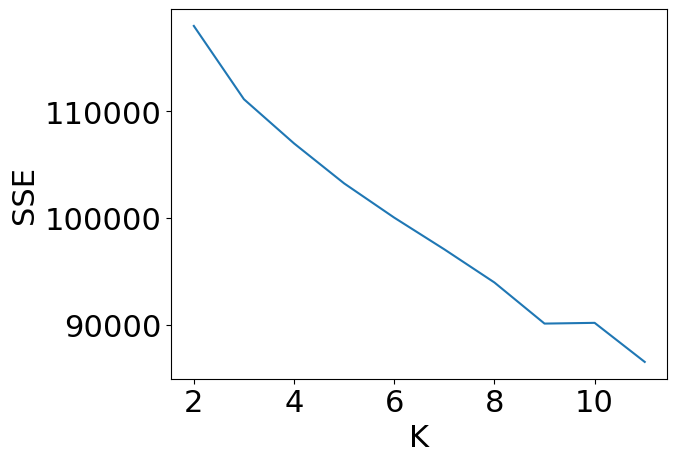

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse_list = list()
max_k = 11
for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100)
    kmeans.fit(X_scaled)
    
    sse = kmeans.inertia_
    sse_list.append(sse)

plt.plot(range(2, len(sse_list) + 2), sse_list)
plt.ylabel('SSE', fontsize=22)
plt.xlabel('K', fontsize=22)
plt.tick_params(axis='both', which='major', labelsize=22)
plt.show()

#### Silhouette score

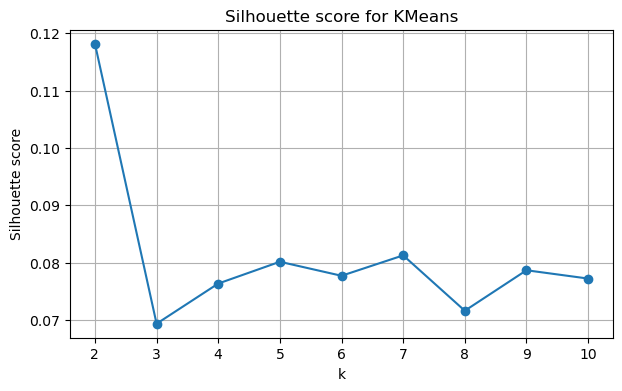

Best k by silhouette: 2


In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Range of k to try
K = range(2, 11)

sil_scores = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Silhouette plot
plt.figure(figsize=(7, 4))
plt.plot(K, sil_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.title('Silhouette score for KMeans')
plt.xticks(list(K))
plt.grid(True)
plt.show()

best_k = K[sil_scores.index(max(sil_scores))]
print("Best k by silhouette:", best_k)


### Characterizations of the clusters 

In [12]:
k_opt = best_k  
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

# Attach cluster labels to the patient dataframe
patients['cluster_kmeans'] = cluster_labels
patients[['subject_id', 'cluster_kmeans']].head()


,subject_id,cluster_kmeans
0,10000980,1
1,10002013,0
2,10002155,0
3,10004457,0
4,10007058,0


In [13]:
cluster_profile = patients.groupby('cluster_kmeans').mean(numeric_only=True)
cluster_profile

,subject_id,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,...,total_tests,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
0,1.503691e+07,22.429485,57.258481,65.335464,35.949981,8.497932,80.546446,11.175254,0.366303,0.269274,...,119.649116,0.273633,4.424032,143.605867,1.148176,0.020836,0.593467,0.197247,2.936066,9.863859
1,1.496545e+07,16.790798,69.140429,69.722086,43.649693,9.821472,76.415951,17.131902,1.527607,0.647853,...,324.120245,0.413314,5.059939,217.337423,2.692638,0.093277,0.741622,0.683103,4.104294,71.850307


### Evaluation of clustering results

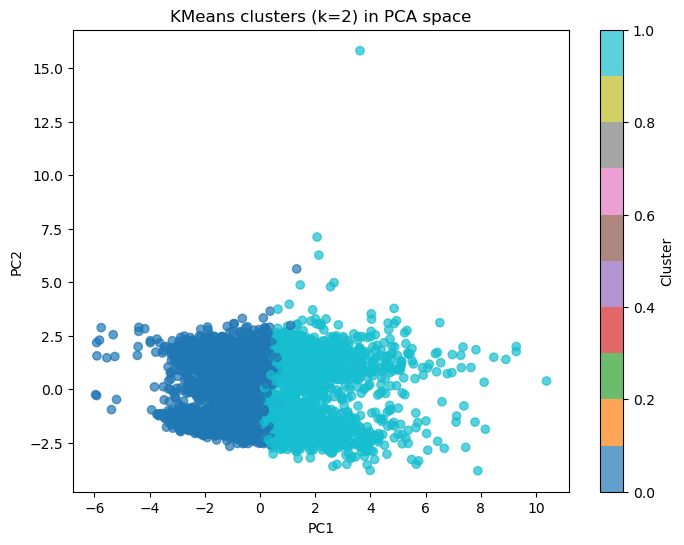

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap='tab10',
    alpha=0.7
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'KMeans clusters (k={k_opt}) in PCA space')
plt.colorbar(scatter, label='Cluster')
plt.show()


**Possible interpretation**

With `k=2`, the clusters essentially represent two broad cardiometabolic risk profiles.

**Cluster 0 (healthier/lower risk)**
Younger patients, with lower hf_severity_max, fewer comorbidities (e.g., lv_dilated, atrial_fibrillation ≈ 0), and fewer total procedures/lab events.

**Cluster 1 (more complex/higher risk)**
Older patients, with higher blood pressure, heart rate, and hf_severity_max, a greater presence of structural comorbidities, and a higher number of tests/procedures; these are the "high-intensity care" patients.

## Clustering analysis: Density-based clustering (DBSCAN)

Before doing the analysis, we tune the hyperparameters (`eps`, `min_samples`) with a grid search. 

In [15]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 8]

best_eps = None
best_min_samples = None
best_sil = -1.0
best_labels = None

results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)

        if n_clusters >= 2 and n_noise < len(labels):
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask])
        else:
            sil = np.nan

        results.append((eps, ms, n_clusters, n_noise, sil))

        # update best combination
        if not np.isnan(sil) and sil > best_sil:
            best_sil = sil
            best_eps = eps
            best_min_samples = ms
            best_labels = labels

# print all results
for r in results:
    print(f"eps={r[0]:.2f}, min_samples={r[1]:2d} -> "
          f"clusters={r[2]}, noise={r[3]}, silhouette={r[4]}")

print("\nBest combination:")
print(f"eps={best_eps}, min_samples={best_min_samples}, silhouette={best_sil}")

eps=0.30, min_samples= 3 -> clusters=0, noise=4289, silhouette=nan
eps=0.30, min_samples= 5 -> clusters=0, noise=4289, silhouette=nan
eps=0.30, min_samples= 8 -> clusters=0, noise=4289, silhouette=nan
eps=0.50, min_samples= 3 -> clusters=1, noise=4286, silhouette=nan
eps=0.50, min_samples= 5 -> clusters=0, noise=4289, silhouette=nan
eps=0.50, min_samples= 8 -> clusters=0, noise=4289, silhouette=nan
eps=0.70, min_samples= 3 -> clusters=5, noise=4274, silhouette=0.781303653670664
eps=0.70, min_samples= 5 -> clusters=0, noise=4289, silhouette=nan
eps=0.70, min_samples= 8 -> clusters=0, noise=4289, silhouette=nan
eps=1.00, min_samples= 3 -> clusters=14, noise=4205, silhouette=0.4130359040945804
eps=1.00, min_samples= 5 -> clusters=5, noise=4258, silhouette=0.45576620029021353
eps=1.00, min_samples= 8 -> clusters=1, noise=4280, silhouette=nan
eps=1.50, min_samples= 3 -> clusters=47, noise=3890, silhouette=0.1966359072996503
eps=1.50, min_samples= 5 -> clusters=10, noise=4063, silhouette=0.2

In [16]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
db_labels = dbscan.fit_predict(X_scaled)

patients['cluster_dbscan'] = db_labels  # save labels (-1 = noise)

# --- basic stats ---
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db = np.sum(db_labels == -1)

print(f"DBSCAN - number of clusters (excluding noise): {n_clusters_db}")
print(f"DBSCAN - number of noise points: {n_noise_db}")

# silhouette only if at least 2 clusters and not all noise
if n_clusters_db >= 2:
    mask_core = db_labels != -1
    sil_db = silhouette_score(X_scaled[mask_core], db_labels[mask_core])
    print(f"DBSCAN silhouette (without noise): {sil_db:.3f}")
else:
    print("Silhouette not meaningful (less than 2 clusters).")


DBSCAN - number of clusters (excluding noise): 5
DBSCAN - number of noise points: 4274
DBSCAN silhouette (without noise): 0.781


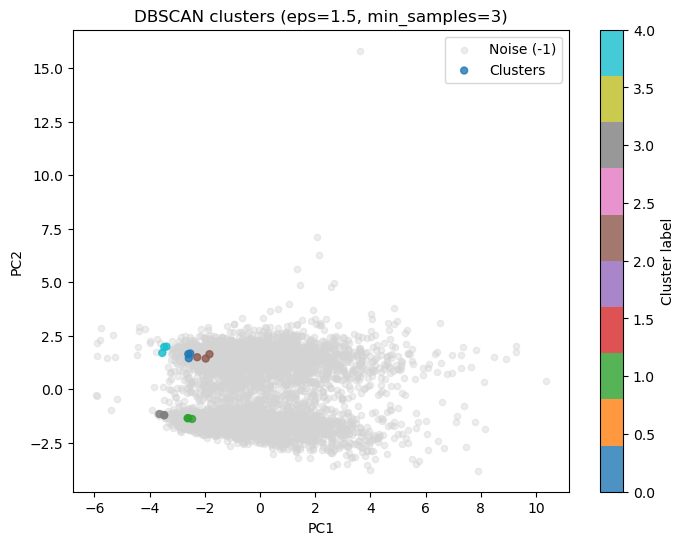

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

mask_noise = db_labels == -1
mask_cluster = ~mask_noise

# noise in grey
plt.scatter(
    X_pca[mask_noise, 0],
    X_pca[mask_noise, 1],
    c='lightgrey',
    s=20,
    alpha=0.4,
    label='Noise (-1)'
)

# clusters with colors
scatter = plt.scatter(
    X_pca[mask_cluster, 0],
    X_pca[mask_cluster, 1],
    c=db_labels[mask_cluster],
    cmap='tab10',
    s=25,
    alpha=0.8,
    label='Clusters'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'DBSCAN clusters (eps={eps}, min_samples={best_min_samples})')
plt.legend()
plt.colorbar(scatter, label='Cluster label')
plt.show()


In [18]:
dbscan_profile = (
    patients[patients['cluster_dbscan'] != -1]
    .groupby('cluster_dbscan')
    .mean(numeric_only=True)
    .round(2)
)

display(dbscan_profile)

# cluster sizes
patients['cluster_dbscan'].value_counts().sort_index()

,subject_id,age,temp_max,sbp_max,hr_max,rr_max,spo2_min,lvef_min,hf_severity_max,lv_dilated,...,perc_invalid,k_max,glu_max,creat_max,k_abnormal_ratio,glu_abnormal_ratio,creat_abnormal_ratio,total_procedures,n_days_span_y,cluster_kmeans
cluster_dbscan,,,,,,,,,,,,,,,,,,,,,
0,11726676.67,0.0,98.50,114.67,73.0,17.33,98.33,0.0,0.0,0.0,...,0.27,4.27,92.67,0.97,0.0,0.0,0.0,3.33,0.33,0.0
1,12692411.00,0.0,0.00,0.00,0.0,0.00,94.33,0.0,1.0,0.0,...,0.24,4.37,97.33,1.13,0.0,0.0,0.0,0.00,0.00,0.0
2,12464410.00,0.0,97.50,139.67,61.0,16.33,96.00,0.0,0.0,0.0,...,0.26,4.43,123.67,1.10,0.0,1.0,0.0,0.67,0.00,0.0
3,14578421.33,0.0,0.00,0.00,0.0,0.00,99.00,0.0,0.0,0.0,...,0.10,4.07,97.00,0.93,0.0,0.0,0.0,2.00,0.00,0.0
4,14459640.67,0.0,98.57,128.00,69.0,18.67,97.00,0.0,0.0,0.0,...,0.06,4.07,95.00,0.77,0.0,0.0,0.0,0.00,0.00,0.0


cluster_dbscan
-1    4274
 0       3
 1       3
 2       3
 3       3
 4       3
Name: count, dtype: int64

## Clustering analysis: Hierarchical clustering

In [19]:
from scipy.stats import mode
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

#### Complete linkage

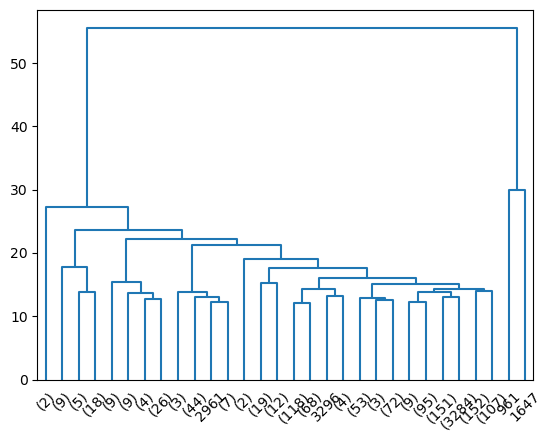

In [20]:
data_dist = pdist(X_scaled, metric='euclidean')
data_link = linkage(data_dist, method='complete', metric='euclidean')
res = dendrogram(data_link, color_threshold=1.0, truncate_mode='lastp')

#### Single link

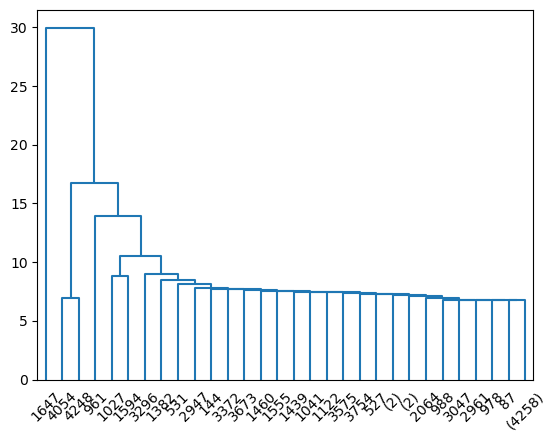

In [21]:
data_dist = pdist(X_scaled, metric='euclidean')
data_link = linkage(data_dist, method='single', metric='euclidean')
res = dendrogram(data_link, color_threshold=0.2, truncate_mode='lastp')

#### Average

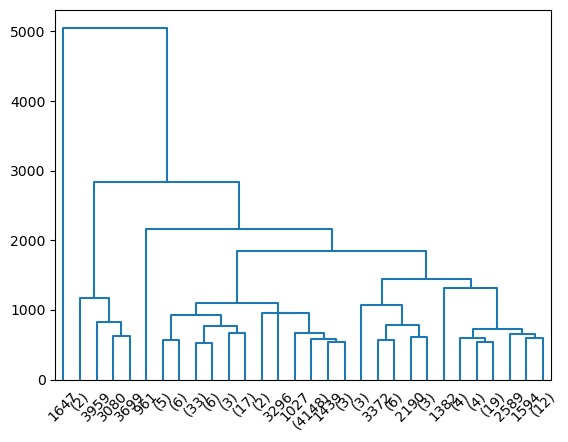

In [22]:
data_dist = pdist(X, metric='euclidean')
data_link = linkage(data_dist, method='average', metric='euclidean')
res = dendrogram(data_link, color_threshold=0.4, truncate_mode='lastp')

In [23]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import numpy as np

linkages = ['ward', 'complete', 'average']
K = range(2, 11)

results_hc = []
best_link = None
best_k = None
best_sil = -1
best_labels = None

for link in linkages:
    for k in K:
        if link == 'ward':
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage='ward'
            )
        else:
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=link,
                metric='euclidean'
            )

        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)

        results_hc.append((link, k, sil))
        print(f"linkage={link:8s}, k={k} -> silhouette={sil:.3f}")

        if sil > best_sil:
            best_sil = sil
            best_link = link
            best_k = k
            best_labels = labels

print("\nBest hierarchical configuration:")
print(f"linkage={best_link}, k={best_k}, silhouette={best_sil:.3f}")

patients['cluster_hier'] = best_labels


linkage=ward    , k=2 -> silhouette=0.167
linkage=ward    , k=3 -> silhouette=0.170
linkage=ward    , k=4 -> silhouette=0.041
linkage=ward    , k=5 -> silhouette=0.054
linkage=ward    , k=6 -> silhouette=0.060
linkage=ward    , k=7 -> silhouette=0.063
linkage=ward    , k=8 -> silhouette=0.068
linkage=ward    , k=9 -> silhouette=0.066
linkage=ward    , k=10 -> silhouette=0.072
linkage=complete, k=2 -> silhouette=0.800
linkage=complete, k=3 -> silhouette=0.676
linkage=complete, k=4 -> silhouette=0.664
linkage=complete, k=5 -> silhouette=0.397
linkage=complete, k=6 -> silhouette=0.377
linkage=complete, k=7 -> silhouette=0.250
linkage=complete, k=8 -> silhouette=0.250
linkage=complete, k=9 -> silhouette=0.249
linkage=complete, k=10 -> silhouette=0.238
linkage=average , k=2 -> silhouette=0.855
linkage=average , k=3 -> silhouette=0.676
linkage=average , k=4 -> silhouette=0.664
linkage=average , k=5 -> silhouette=0.570
linkage=average , k=6 -> silhouette=0.508
linkage=average , k=7 -> silhoue

In [24]:
hc = AgglomerativeClustering(
    n_clusters=best_k,
    linkage=best_link,
    metric='euclidean' if best_link != 'ward' else None
)
hc_labels = hc.fit_predict(X_scaled)

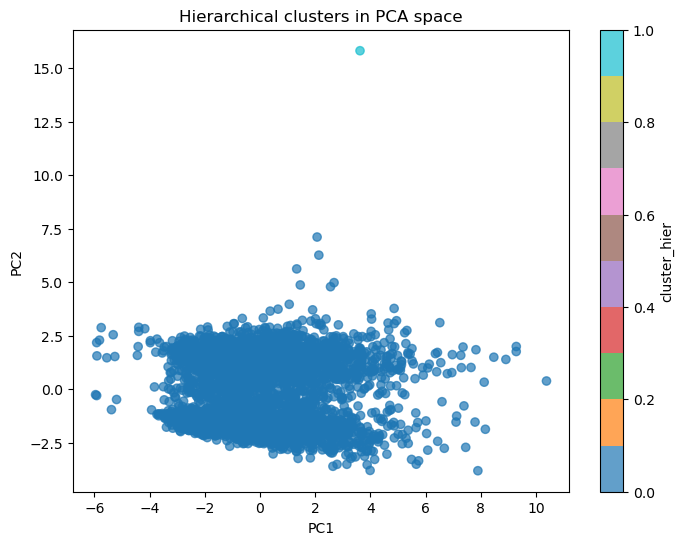

In [25]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hc_labels,        
    cmap='tab10',
    alpha=0.7
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical clusters in PCA space')
plt.colorbar(scatter, label='cluster_hier')
plt.show()

## Final evaluation

To be done

## **Optional**: alternative clustering

We use `pyclustering` to explore other various type of clustering.  

In [26]:
!pip install pyclustering

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 1.6 MB/s  0:00:01 eta 0:00:01
  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'pyclustering' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'pyclustering'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for pyclustering: filename=pyclustering-0.10.1.2-py3-none-any.whl size=2395101 sha256=c068745a9c73558bccdb61210f021ae8672d0ace3dcd4f61e0b72bb6ed3d12a6
  Stored in directory: /home/gabriele/.cache/pip/wheels/82/ff/9c/fb3aedfa7966808cbd411ebca7df35bf731fe9e01c2cd699ee
Successfully built pyclustering


### X-means

`X-means` can provide useful information. It extends KMeans and automatically chooses the number of clusters using BIC-like criteria (*Bayesian Information Criterion*).

In [ ]:
from pyclustering.cluster.xmeans import xmeans, kmeans_plusplus_initializer
import numpy as np
import warnings
np.warnings = warnings

data = X_scaled.values

initial_centers = kmeans_plusplus_initializer(
    data,
    amount_centers=2      # starting k (e.g. 2)
).initialize()

xmeans_instance = xmeans(
    data=data,
    initial_centers=initial_centers,
    kmax=10               # maximum clusters to search
)

xmeans_instance.process()

clusters = xmeans_instance.get_clusters()       # list of lists of indices
centers  = xmeans_instance.get_centers()

print(f"Found {len(clusters)} clusters")


Found 10 clusters


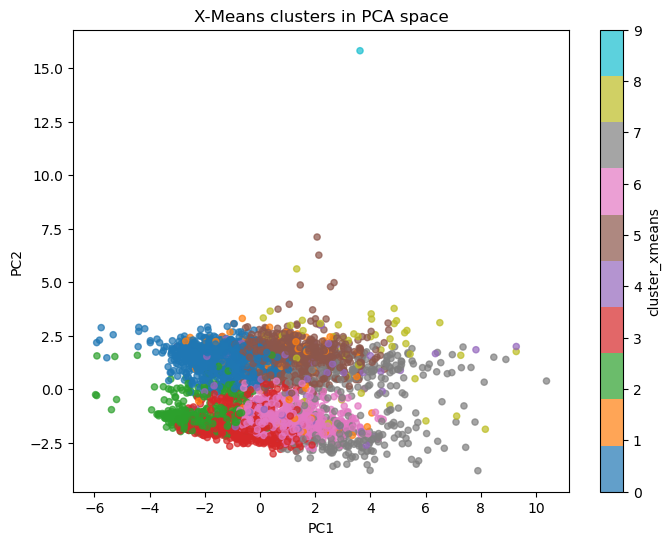

In [34]:
labels_xmeans = np.empty(data.shape[0], dtype=int)
for idx_cluster, indices in enumerate(clusters):
    labels_xmeans[indices] = idx_cluster

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=labels_xmeans, cmap='tab10', alpha=0.7, s=20)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('X-Means clusters in PCA space')
plt.colorbar(scatter, label='cluster_xmeans')
plt.show()

### CURE

### GMeans